In [1]:
#In your monthly model output find the SF<species> --> monthly model output: 
#where species is:
#NH3
#NO2 and NO -- (convert to N and sum these for NOx),
# pom_a4
#bc_a4
#SO2
#SO4 (sum so4_a1 and so4_a2, no conversion necessary here).
#Sum over CONUS in the model for month average values (don't extract at sites) then calculate a trend.

In [2]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
from fnmatch import fnmatch
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
def process_daily_files(result_dir, files_to_open, variables_to_select, progress_bar=None):
    # Open the daily files as an xarray dataset
    ds = xr.open_mfdataset(str(result_dir / files_to_open), combine='nested')

    # Select specific variables
    ds = ds[variables_to_select]

    # Update progress bar
    if progress_bar:
        progress_bar.update(1)
    return ds

In [4]:
#Look at monthly data (h0) variables
result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/atm_h0')
file = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam.h0.2022-12.nc'
file_to_open = result_dir / file
nc_load = xr.open_dataset(file_to_open, engine='netcdf4')
nc_load.data_vars

/glade/u/home/demurray/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
ecCodes library not found using ['eccodes', 'libeccodes.so', 'libeccodes']
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Data variables:
    gw                       (lat) float64 ...
    hyam                     (lev) float64 ...
    hybm                     (lev) float64 ...
    P0                       float64 ...
    hyai                     (ilev) float64 ...
    hybi                     (ilev) float64 ...
    date                     (time) int32 ...
    datesec                  (time) int32 ...
    time_bnds                (time, nbnd) datetime64[ns] ...
    date_written             (time) |S8 ...
    time_written             (time) |S8 ...
    ndbase                   int32 ...
    nsbase                   int32 ...
    nbdate                   int32 ...
    nbsec                    int32 ...
    mdt                      int32 ...
    ndcur                    (time) int32 ...
    nscur                    (time) int32 ...
    co2vmr                   (time) float64 ...
    ch4vmr                   (time) float64 ...
    n2ovmr                   (time) float64 ...
    f11vmr                   (time

In [5]:
result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/atm_h0')

files_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam.h0.*.nc'
variables_to_select = ['SFNH3', 'SFNO', 'SFSO2', 'SFbc_a4', 'SFpom_a4', 'SFso4_a1', 'SFso4_a2']

files_list = list(result_dir.glob(files_to_open))

# Initialize tqdm progress bar
progress = tqdm(total=len(files_list))

processed_data = []
for file in files_list:
    processed_data.append(process_daily_files(result_dir, file.relative_to(result_dir), variables_to_select, progress_bar=progress))

progress.close()

nc_monthly_SF = xr.concat(processed_data, dim='time').sortby('time')


100%|██████████| 252/252 [02:04<00:00,  2.02it/s]


In [6]:
#Perform some conversions --> SO4 (sum so4_a1 and so4_a2, no conversion necessary here).
nc_monthly_SF['SFSO4'] = nc_monthly_SF['SFso4_a1'] + nc_monthly_SF['SFso4_a2']
nc_monthly_SF = nc_monthly_SF[['SFNH3', 'SFNO', 'SFSO2', 'SFbc_a4', 'SFpom_a4', 'SFSO4']]
nc_monthly_SF

<xarray.Dataset>
Dimensions:   (time: 252, lat: 192, lon: 288)
Coordinates:
  * lat       (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time      (time) datetime64[ns] 2002-02-01 2002-03-01 ... 2023-01-01
Data variables:
    SFNH3     (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    SFNO      (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    SFSO2     (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    SFbc_a4   (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    SFpom_a4  (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    SFSO4     (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001
    logname:           demurray
    host:              derecho6
    initial_file:      /glade/campaign/acom/acom-climate/UTLS/shawnh/archive/...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

In [7]:
#Subset for cells only in CONUS bounding box

#Right now just bounding the data by lat and lon min/max of CONUS, but this includes cells with water, so idk if its
#totally approporiate, would need to upload a land-sea mask and subset cells by this mask too

# Apply CONUS bounds
nc_monthly_SF_conus = nc_monthly_SF.where(
    (nc_monthly_SF.lat >= 24.5) & (nc_monthly_SF.lat <= 49.5) & 
    (nc_monthly_SF.lon >= 235) & (nc_monthly_SF.lon <= 293), 
    drop=True
)

#Correct timestamp (offset by 1 month)
#nc_monthly_SF_conus['time2'] = pd.to_datetime(nc_monthly_SF_conus['time'].values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1)

# Check the new dataset dimensions - should be smaller (and it is!)
nc_monthly_SF_conus

<xarray.Dataset>
Dimensions:   (time: 252, lat: 27, lon: 47)
Coordinates:
  * lat       (lat) float64 24.97 25.92 26.86 27.8 ... 46.65 47.59 48.53 49.48
  * lon       (lon) float64 235.0 236.2 237.5 238.8 ... 288.8 290.0 291.2 292.5
  * time      (time) datetime64[ns] 2002-02-01 2002-03-01 ... 2023-01-01
Data variables:
    SFNH3     (time, lat, lon) float32 dask.array<chunksize=(1, 27, 47), meta=np.ndarray>
    SFNO      (time, lat, lon) float32 dask.array<chunksize=(1, 27, 47), meta=np.ndarray>
    SFSO2     (time, lat, lon) float32 dask.array<chunksize=(1, 27, 47), meta=np.ndarray>
    SFbc_a4   (time, lat, lon) float32 dask.array<chunksize=(1, 27, 47), meta=np.ndarray>
    SFpom_a4  (time, lat, lon) float32 dask.array<chunksize=(1, 27, 47), meta=np.ndarray>
    SFSO4     (time, lat, lon) float32 dask.array<chunksize=(1, 27, 47), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001
    logname:           demurray
    host:              derecho6
    initial_file:      /glade/campaign/acom/acom-climate/UTLS/shawnh/archive/...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

In [8]:
#Calculate monthly average values across CONUS --> group by time2 and calculate average 
nc_monthly_SF_conus_avg = nc_monthly_SF_conus.mean(dim=('lat', 'lon'))
nc_monthly_SF_conus_avg = nc_monthly_SF_conus_avg.sortby("time")  # Ensure time is sorted
nc_monthly_SF_conus_avg

<xarray.Dataset>
Dimensions:   (time: 252)
Coordinates:
  * time      (time) datetime64[ns] 2002-02-01 2002-03-01 ... 2023-01-01
Data variables:
    SFNH3     (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    SFNO      (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    SFSO2     (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    SFbc_a4   (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    SFpom_a4  (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    SFSO4     (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>

/glade/derecho/scratch/demurray/tmp/ipykernel_52704/1573524155.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope, intercept = model.params[1], model.params[0]


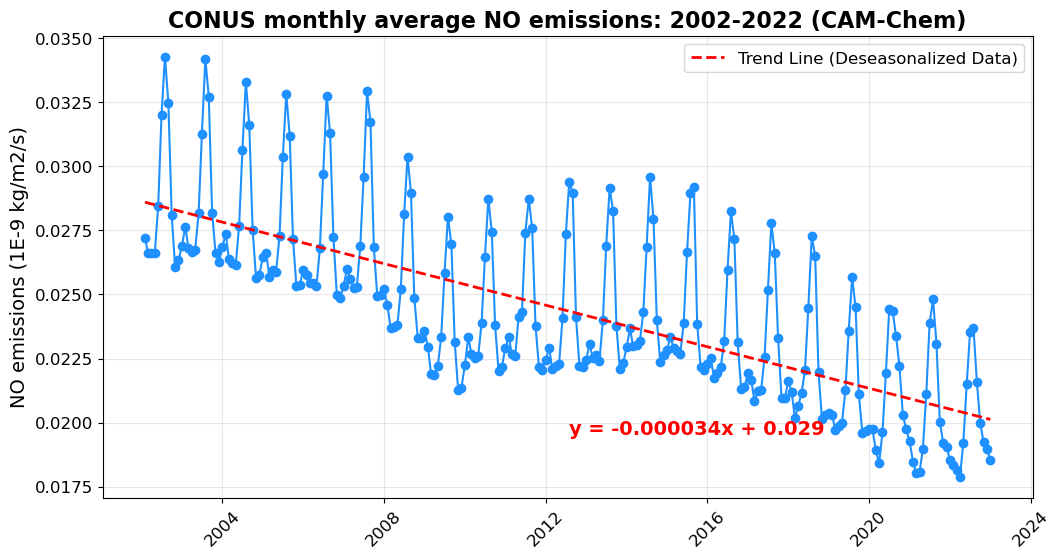

In [9]:
#NO emissions
sfno = nc_monthly_SF_conus_avg["SFNO"]*1e09

# Convert SFNO to Pandas Series (for easier manipulation)
sfno_series = sfno.to_series()

# Apply seasonal decomposition (assuming monthly seasonality)
decomposed = seasonal_decompose(sfno_series, model="additive", period=12)  # Monthly seasonality

# Extract deseasonalized values (raw - seasonal component)
deseasonalized_values = sfno_series - decomposed.seasonal

# Fit linear regression on deseasonalized data
time_numeric = np.arange(len(deseasonalized_values))
X = sm.add_constant(time_numeric)
model = sm.OLS(deseasonalized_values, X).fit()
trend_line = model.predict(X)

# Get regression equation
slope, intercept = model.params[1], model.params[0]
equation_text = f"y = {slope:.6f}x + {intercept:.3f}"

# Plot raw SFNO data
plt.figure(figsize=(12, 6))
plt.plot(sfno.time, sfno.values, marker="o", linestyle="-", color="dodgerblue")

# Overlay trend line from deseasonalized data
plt.plot(sfno.time, trend_line, linestyle="--", color="red", linewidth=2, label="Trend Line (Deseasonalized Data)")

# Add regression equation text
plt.text(sfno.time[len(sfno.time)//2], min(sfno.values) + 0.1*(max(sfno.values)-min(sfno.values)),
         equation_text, fontsize=14, color="red", fontweight="bold")

# Formatting
plt.ylabel("NO emissions (1E-9 kg/m2/s)", fontsize=14)
plt.title("CONUS monthly average NO emissions: 2002-2022 (CAM-Chem)", fontsize=16, fontweight="bold")
plt.grid(alpha=0.3)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/NO_emissions_trend.jpg', format='jpg', dpi=300)  
plt.show()

/glade/derecho/scratch/demurray/tmp/ipykernel_52704/2041608343.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope, intercept = model.params[1], model.params[0]


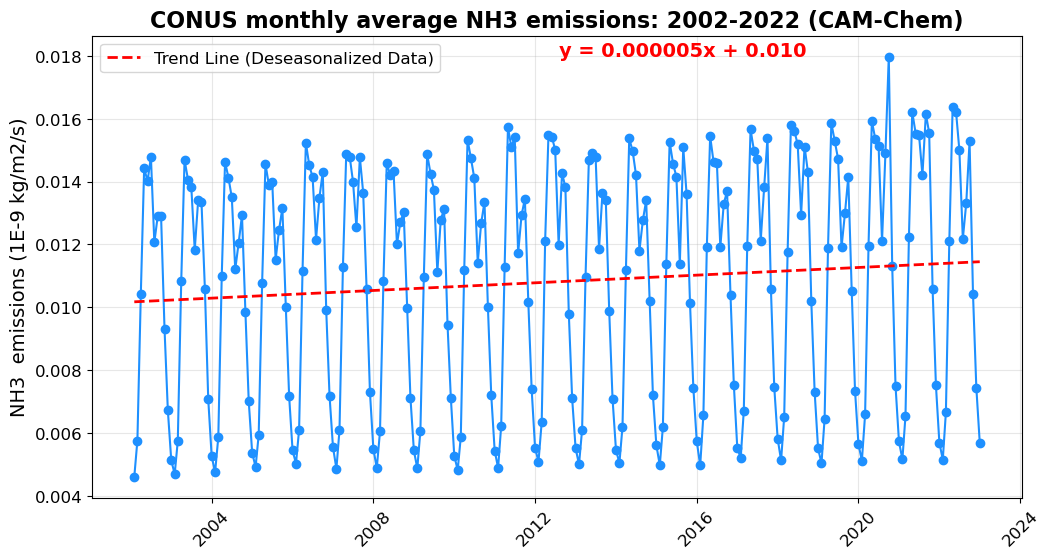

In [10]:
#NH3 emissions
sfnh3 = nc_monthly_SF_conus_avg["SFNH3"]*1e09

# Convert SFNO to Pandas Series (for easier manipulation)
sfnh3_series = sfnh3.to_series()

# Apply seasonal decomposition (assuming monthly seasonality)
decomposed = seasonal_decompose(sfnh3_series, model="additive", period=12)  # Monthly seasonality

# Extract deseasonalized values (raw - seasonal component)
deseasonalized_values = sfnh3_series - decomposed.seasonal

# Fit linear regression on deseasonalized data
time_numeric = np.arange(len(deseasonalized_values))
X = sm.add_constant(time_numeric)
model = sm.OLS(deseasonalized_values, X).fit()
trend_line = model.predict(X)

# Get regression equation
slope, intercept = model.params[1], model.params[0]
equation_text = f"y = {slope:.6f}x + {intercept:.3f}"

# Plot raw data
plt.figure(figsize=(12, 6))
plt.plot(sfnh3.time, sfnh3.values, marker="o", linestyle="-", color="dodgerblue")

# Overlay trend line from deseasonalized data
plt.plot(sfnh3.time, trend_line, linestyle="--", color="red", linewidth=2, label="Trend Line (Deseasonalized Data)")

# Add regression equation text
plt.text(sfnh3.time[len(sfnh3.time)//2], min(sfnh3.values) + (max(sfnh3.values)-min(sfnh3.values)),
         equation_text, fontsize=14, color="red", fontweight="bold")

# Formatting
plt.ylabel("NH3  emissions (1E-9 kg/m2/s)", fontsize=14)
plt.title("CONUS monthly average NH3 emissions: 2002-2022 (CAM-Chem)", fontsize=16, fontweight="bold")
plt.grid(alpha=0.3)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/NH3_emissions_trend.jpg', format='jpg', dpi=300)  
plt.show()

/glade/derecho/scratch/demurray/tmp/ipykernel_52704/2853114990.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope, intercept = model.params[1], model.params[0]


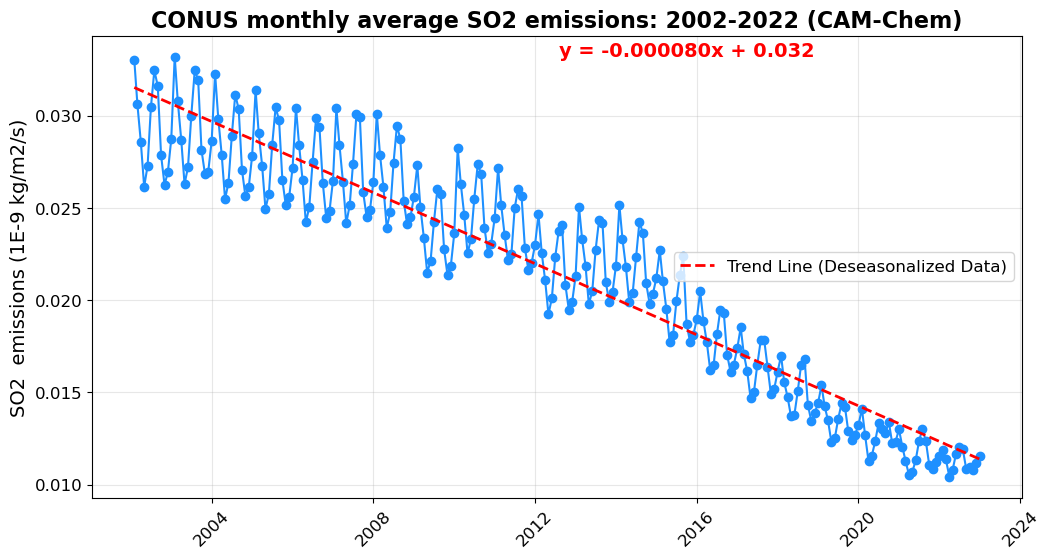

In [11]:
#SO2 emissions
sfso2 = nc_monthly_SF_conus_avg["SFSO2"]*1e09

# Convert SFNO to Pandas Series (for easier manipulation)
sfso2_series = sfso2.to_series()

# Apply seasonal decomposition (assuming monthly seasonality)
decomposed = seasonal_decompose(sfso2_series, model="additive", period=12)  # Monthly seasonality

# Extract deseasonalized values (raw - seasonal component)
deseasonalized_values = sfso2_series - decomposed.seasonal

# Fit linear regression on deseasonalized data
time_numeric = np.arange(len(deseasonalized_values))
X = sm.add_constant(time_numeric)
model = sm.OLS(deseasonalized_values, X).fit()
trend_line = model.predict(X)

# Get regression equation
slope, intercept = model.params[1], model.params[0]
equation_text = f"y = {slope:.6f}x + {intercept:.3f}"

# Plot raw data
plt.figure(figsize=(12, 6))
plt.plot(sfso2.time, sfso2.values, marker="o", linestyle="-", color="dodgerblue")

# Overlay trend line from deseasonalized data
plt.plot(sfso2.time, trend_line, linestyle="--", color="red", linewidth=2, label="Trend Line (Deseasonalized Data)")

# Add regression equation text
plt.text(sfso2.time[len(sfso2.time)//2], min(sfso2.values) + (max(sfso2.values)-min(sfso2.values)),
         equation_text, fontsize=14, color="red", fontweight="bold")

# Formatting
plt.ylabel("SO2  emissions (1E-9 kg/m2/s)", fontsize=14)
plt.title("CONUS monthly average SO2 emissions: 2002-2022 (CAM-Chem)", fontsize=16, fontweight="bold")
plt.grid(alpha=0.3)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='center right')
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/SO2_emissions_trend.jpg', format='jpg', dpi=300)  
plt.show()

/glade/derecho/scratch/demurray/tmp/ipykernel_52704/3901646246.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope, intercept = model.params[1], model.params[0]


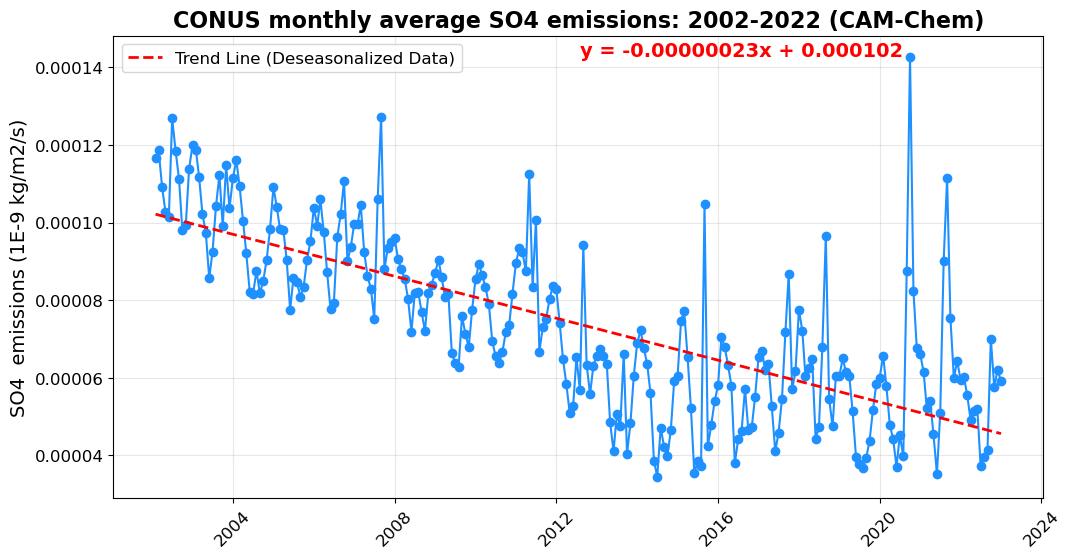

In [12]:
#SO4 emissions
sfso4 = nc_monthly_SF_conus_avg["SFSO4"]*1e09

# Convert SFNO to Pandas Series (for easier manipulation)
sfso4_series = sfso4.to_series()

# Apply seasonal decomposition (assuming monthly seasonality)
decomposed = seasonal_decompose(sfso4_series, model="additive", period=12)  # Monthly seasonality

# Extract deseasonalized values (raw - seasonal component)
deseasonalized_values = sfso4_series - decomposed.seasonal

# Fit linear regression on deseasonalized data
time_numeric = np.arange(len(deseasonalized_values))
X = sm.add_constant(time_numeric)
model = sm.OLS(deseasonalized_values, X).fit()
trend_line = model.predict(X)

# Get regression equation
slope, intercept = model.params[1], model.params[0]
equation_text = f"y = {slope:.8f}x + {intercept:.6f}"

# Plot raw data
plt.figure(figsize=(12, 6))
plt.plot(sfso4.time, sfso4.values, marker="o", linestyle="-", color="dodgerblue")

# Overlay trend line from deseasonalized data
plt.plot(sfso4.time, trend_line, linestyle="--", color="red", linewidth=2, label="Trend Line (Deseasonalized Data)")

# Add regression equation text
plt.text(sfso4.time[len(sfso4.time)//2], min(sfso4.values) + (max(sfso4.values)-min(sfso4.values)),
         equation_text, fontsize=14, color="red", fontweight="bold")

# Formatting
plt.ylabel("SO4  emissions (1E-9 kg/m2/s)", fontsize=14)
plt.title("CONUS monthly average SO4 emissions: 2002-2022 (CAM-Chem)", fontsize=16, fontweight="bold")
plt.grid(alpha=0.3)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/SO4_emissions_trend.jpg', format='jpg', dpi=300)  
plt.show()

/glade/derecho/scratch/demurray/tmp/ipykernel_52704/2605763444.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope, intercept = model.params[1], model.params[0]


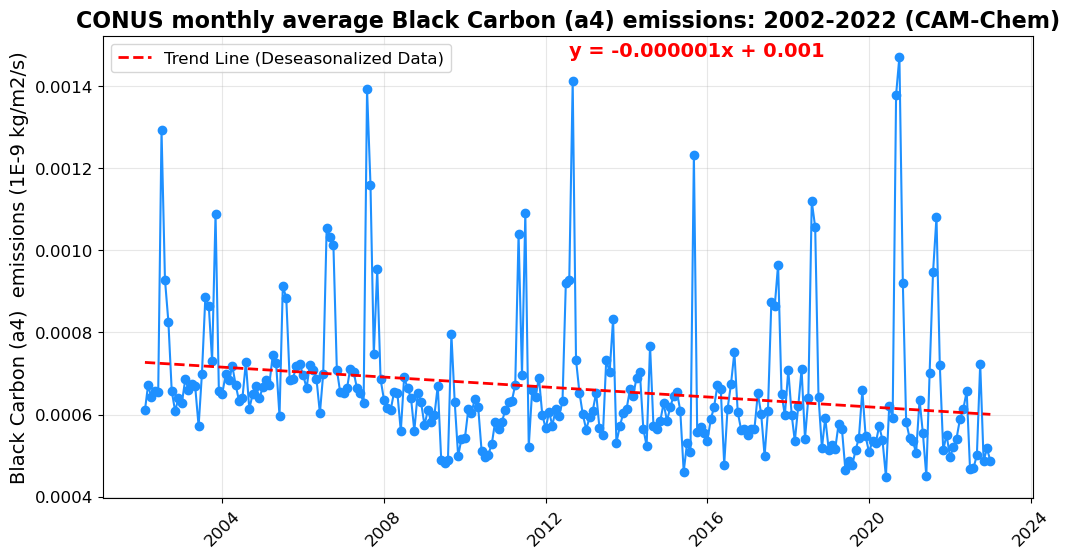

In [13]:
#bc_a4 emissions
sfbc_a4 = nc_monthly_SF_conus_avg["SFbc_a4"]*1e09

# Convert SFNO to Pandas Series (for easier manipulation)
sfbc_a4_series = sfbc_a4.to_series()

# Apply seasonal decomposition (assuming monthly seasonality)
decomposed = seasonal_decompose(sfbc_a4_series, model="additive", period=12)  # Monthly seasonality

# Extract deseasonalized values (raw - seasonal component)
deseasonalized_values = sfbc_a4_series - decomposed.seasonal

# Fit linear regression on deseasonalized data
time_numeric = np.arange(len(deseasonalized_values))
X = sm.add_constant(time_numeric)
model = sm.OLS(deseasonalized_values, X).fit()
trend_line = model.predict(X)

# Get regression equation
slope, intercept = model.params[1], model.params[0]
equation_text = f"y = {slope:.6f}x + {intercept:.3f}"

# Plot raw data
plt.figure(figsize=(12, 6))
plt.plot(sfbc_a4.time, sfbc_a4.values, marker="o", linestyle="-", color="dodgerblue")

# Overlay trend line from deseasonalized data
plt.plot(sfbc_a4.time, trend_line, linestyle="--", color="red", linewidth=2, label="Trend Line (Deseasonalized Data)")

# Add regression equation text
plt.text(sfbc_a4.time[len(sfbc_a4.time)//2], min(sfbc_a4.values) + (max(sfbc_a4.values)-min(sfbc_a4.values)),
         equation_text, fontsize=14, color="red", fontweight="bold")

# Formatting
plt.ylabel("Black Carbon (a4)  emissions (1E-9 kg/m2/s)", fontsize=14)
plt.title("CONUS monthly average Black Carbon (a4) emissions: 2002-2022 (CAM-Chem)", fontsize=16, fontweight="bold")
plt.grid(alpha=0.3)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/bc_a4_emissions_trend.jpg', format='jpg', dpi=300)  
plt.show()

/glade/derecho/scratch/demurray/tmp/ipykernel_52704/3992780785.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope, intercept = model.params[1], model.params[0]


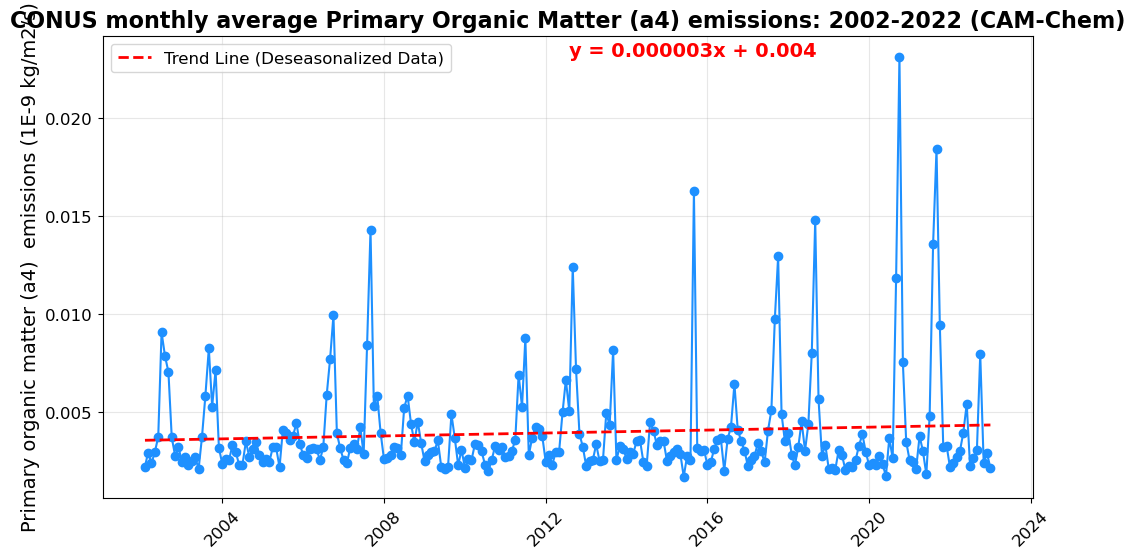

In [14]:
#pom_a4 emissions
sfpom_a4 = nc_monthly_SF_conus_avg["SFpom_a4"]*1e09

# Convert SFNO to Pandas Series (for easier manipulation)
sfpom_a4_series = sfpom_a4.to_series()

# Apply seasonal decomposition (assuming monthly seasonality)
decomposed = seasonal_decompose(sfpom_a4_series, model="additive", period=12)  # Monthly seasonality

# Extract deseasonalized values (raw - seasonal component)
deseasonalized_values = sfpom_a4_series - decomposed.seasonal

# Fit linear regression on deseasonalized data
time_numeric = np.arange(len(deseasonalized_values))
X = sm.add_constant(time_numeric)
model = sm.OLS(deseasonalized_values, X).fit()
trend_line = model.predict(X)

# Get regression equation
slope, intercept = model.params[1], model.params[0]
equation_text = f"y = {slope:.6f}x + {intercept:.3f}"

# Plot raw data
plt.figure(figsize=(12, 6))
plt.plot(sfpom_a4.time, sfpom_a4.values, marker="o", linestyle="-", color="dodgerblue")

# Overlay trend line from deseasonalized data
plt.plot(sfpom_a4.time, trend_line, linestyle="--", color="red", linewidth=2, label="Trend Line (Deseasonalized Data)")

# Add regression equation text
plt.text(sfpom_a4.time[len(sfpom_a4.time)//2], min(sfpom_a4.values) + (max(sfpom_a4.values)-min(sfpom_a4.values)),
         equation_text, fontsize=14, color="red", fontweight="bold")

# Formatting
plt.ylabel("Primary organic matter (a4)  emissions (1E-9 kg/m2/s)", fontsize=14)
plt.title("CONUS monthly average Primary Organic Matter (a4) emissions: 2002-2022 (CAM-Chem)", fontsize=16, fontweight="bold")
plt.grid(alpha=0.3)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/pom_a4_emissions_trend.jpg', format='jpg', dpi=300)  
plt.show()